# Simple demonstration of what Amplitude Modulation Actually looks like

In [1]:
from pathlib import Path
import sys, csv

COURSEUTILS_DIR = Path.home() / "Documents/GitHub/Signals_and_Systems/courseutils"
sys.path.insert(0, str(COURSEUTILS_DIR))

import basic_material as bm
bm.setup_environment()

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [2]:
t_dense = np.linspace(0,2,10**5)  #       

In [3]:
sig = np.sin(2 * np.pi * t_dense)
y_signal = 0.5 + 0.25*signal.square(2 * np.pi * 10 * t_dense, duty=(sig + 1)/2)
y_carrier = np.cos(2*np.pi*500*t_dense)
y_modulated = y_signal*y_carrier

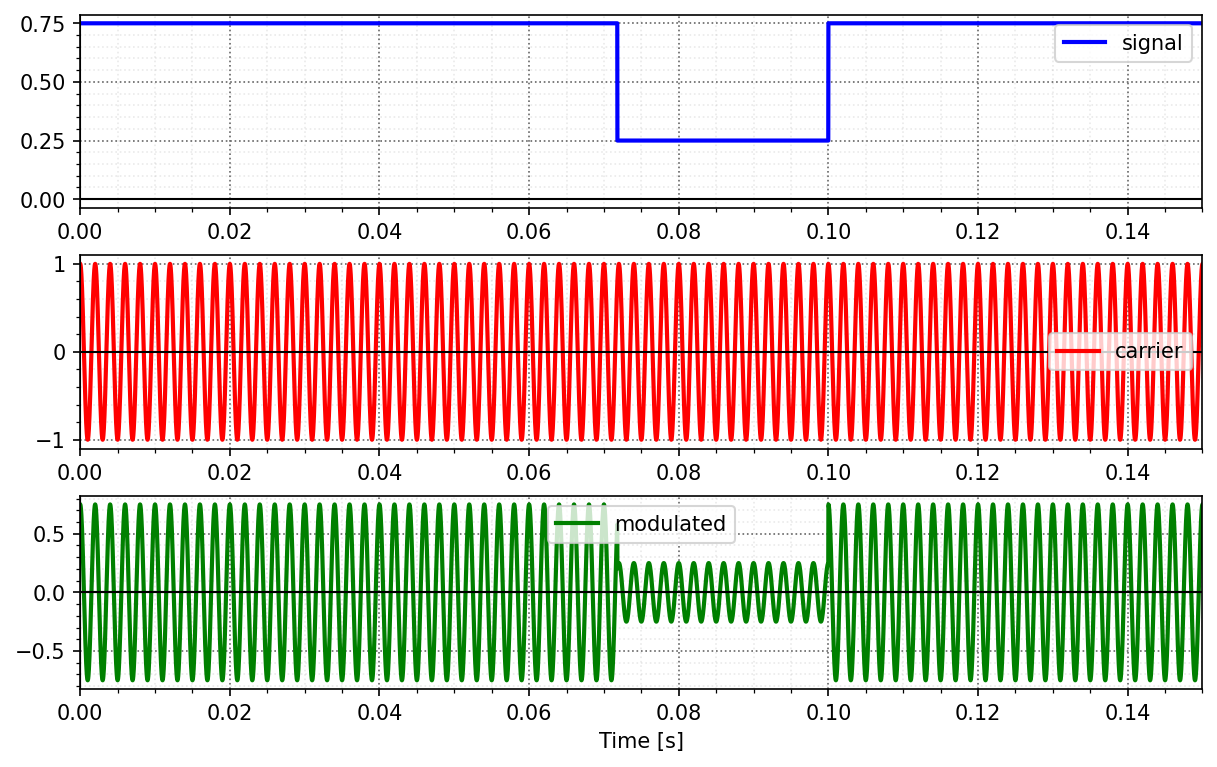

In [4]:
fig, axs = plt.subplots(3,1,figsize=(8, 5),dpi=150,constrained_layout = True)
axs[0].plot(t_dense,y_signal,'b-',lw=2,label='signal')
axs[1].plot(t_dense,y_carrier,'r-',lw=2,label='carrier')
axs[2].plot(t_dense,y_modulated,'g-',lw=2,label='modulated')
for ii in np.arange(3):
    axs[ii].legend()
    axs[ii].set_xlim([0,.15])
    bm.nicegrid(axs[ii])
bm.nicegrid()
axs[-1].set_xlabel("Time [s]")
plt.savefig('./figs/AM_1.pdf',  format='pdf', bbox_inches='tight', dpi=300)
plt.show()

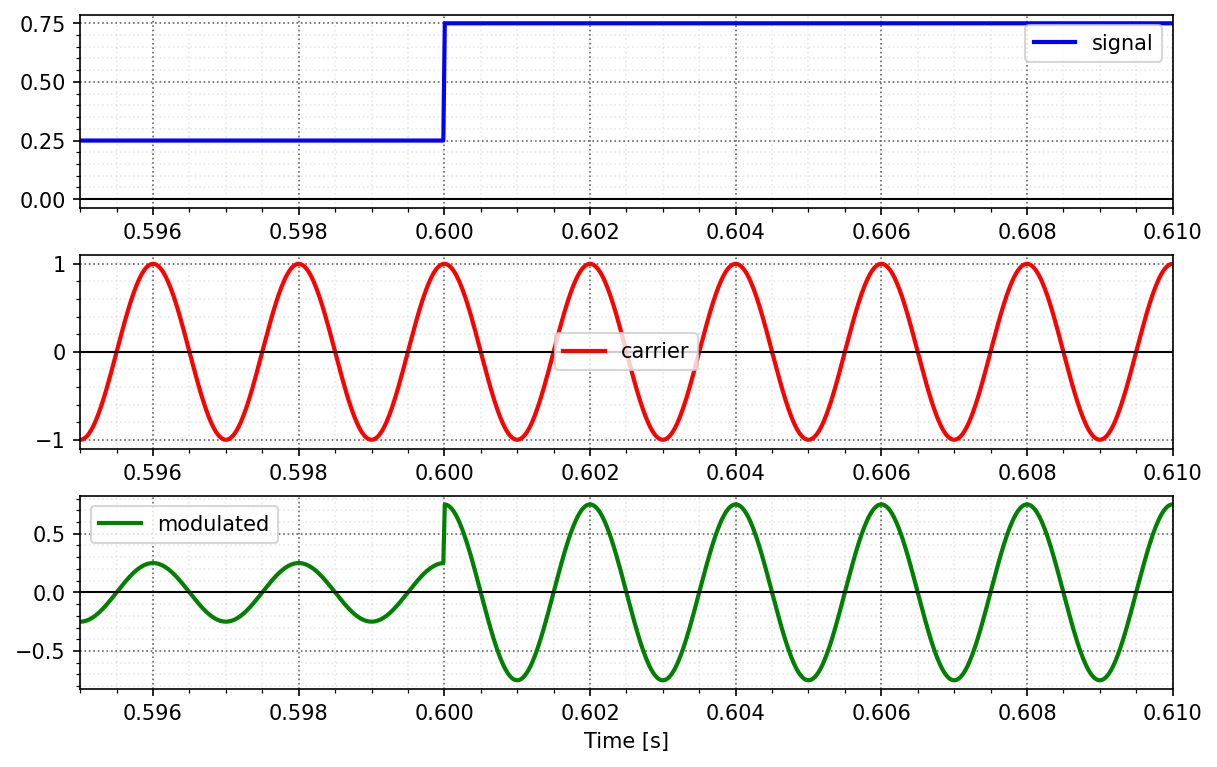

In [5]:
fig, axs = plt.subplots(3,1,figsize=(8, 5),dpi=150,constrained_layout = True)
axs[0].plot(t_dense,y_signal,'b-',lw=2,label='signal')
axs[1].plot(t_dense,y_carrier,'r-',lw=2,label='carrier')
axs[2].plot(t_dense,y_modulated,'g-',lw=2,label='modulated')
for ii in np.arange(3):
    axs[ii].legend()
    axs[ii].set_xlim([.595,.61])
    bm.nicegrid(axs[ii])
axs[-1].set_xlabel("Time [s]")
plt.savefig('./figs/AM_2.pdf',  format='pdf', bbox_inches='tight', dpi=300)
plt.show()

In [6]:
def morse(message):
    """Generate a Morse code signal for a given message."""
    morse_dict = {
        'A': '.-', 'B': '-...', 'C': '-.-.', 'D': '-..', 'E': '.', 
        'F': '..-.', 'G': '--.', 'H': '....', 'I': '..', 'J': '.---', 
        'K': '-.-', 'L': '.-..', 'M': '--', 'N': '-.', 'O': '---', 
        'P': '.--.', 'Q': '--.-', 'R': '.-.', 'S': '...', 'T': '-', 
        'U': '..-', 'V': '...-', 'W': '.--', 'X': '-..-', 'Y': '-.--', 
        'Z': '--..',
        '1': '.----', '2': '..---', '3': '...--', '4': '....-', 
        '5': '.....', '6': '-....', '7': '--...', '8': '---..', 
        '9': '----.', '0': '-----',
        ', ': '--..--', '.': '.-.-.-', '?': '..--..', '/': '-..-.', 
        '-': '-....-', '(':'-.--.', ')':'-.--.-'
    }
    
    message='SOS'
    # Convert message to Morse code
    morse_code = []
    for char in message.upper():
        if char in morse_dict:
            morse_code.append(morse_dict[char])
        elif char == " ":
            morse_code.append(" ")  # Space between words
    return " ".join(morse_code)
morse_code = morse("SOS")
morse_code


'... --- ...'

In [7]:
# Build an on/off message envelope from the Morse string, then modulate a carrier.
#
# Standard Morse timing, measured in units of one "dot":
#   dot = 1, dash = 3, gap between elements of a letter = 1, gap between letters = 3
UNIT = {'.': 1, '-': 3}
GAP_ELEMENT = 1
GAP_LETTER = 3

tf = 10.0        # total duration [s]
fc = 20.0        # carrier frequency [Hz]

# First pass: how many dot units long is the whole word?  Scaling by this makes
# the message fill [0, tf] exactly, whatever the message happens to be.
units = 0
prev_mark = False
for mm in morse_code:
    if mm in UNIT:
        if prev_mark:
            units += GAP_ELEMENT      # gap between elements of the same letter
        units += UNIT[mm]
        prev_mark = True
    elif mm == ' ':
        units += GAP_LETTER           # gap between letters
        prev_mark = False

dot = tf / units
dash = 3 * dot

# Second pass: switch the envelope on for each mark
t = np.linspace(0, tf, 4000)
y_message = np.zeros_like(t)

cursor = 0.0
prev_mark = False
for mm in morse_code:
    if mm in UNIT:
        if prev_mark:
            cursor += GAP_ELEMENT * dot
        width = UNIT[mm] * dot
        y_message[(t >= cursor) & (t < cursor + width)] = 1.0
        cursor += width
        prev_mark = True
    elif mm == ' ':
        cursor += GAP_LETTER * dot
        prev_mark = False

# On-off keying: the message multiplies the carrier, exactly as in the AM
# examples above, but with a message that is only ever 0 or 1
y_carrier_morse = np.cos(2 * np.pi * fc * t)
y_modulated_morse = y_message * y_carrier_morse

print(f"'{morse_code}'  ->  {units} dot units,  dot = {dot:.3f} s,  dash = {dash:.3f} s")

'... --- ...'  ->  27 dot units,  dot = 0.370 s,  dash = 1.111 s


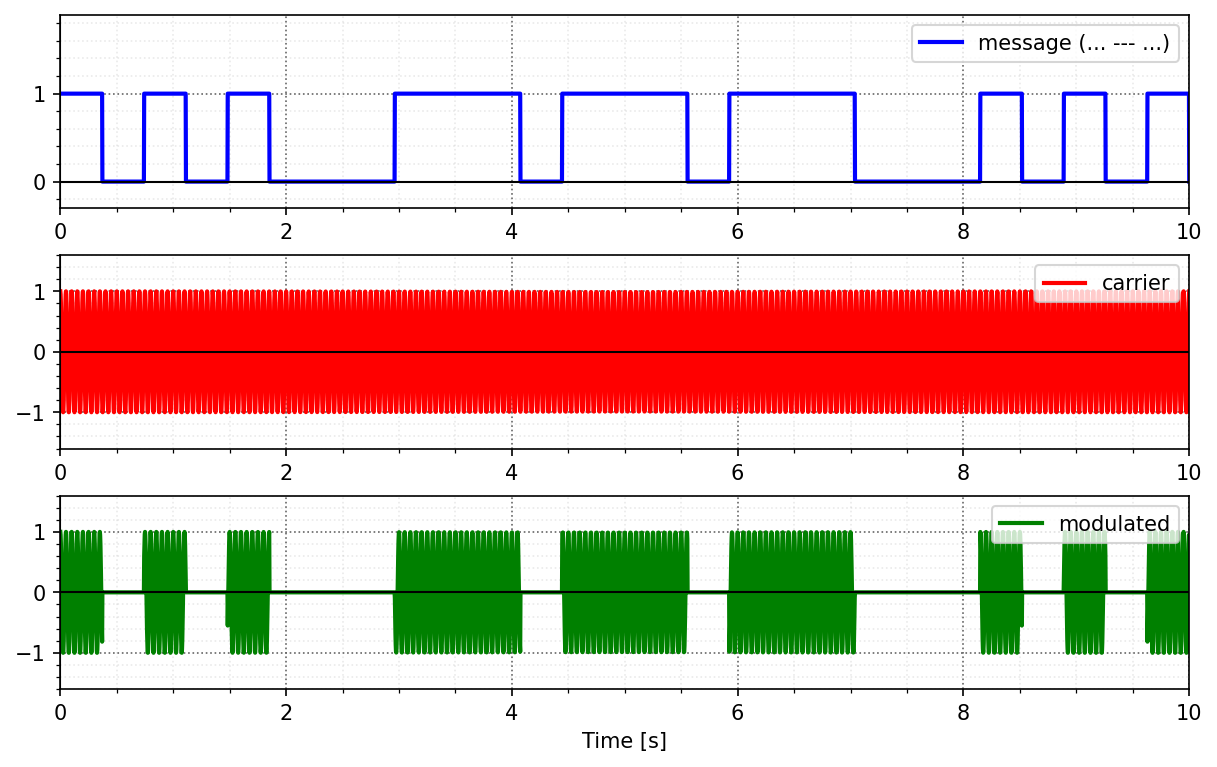

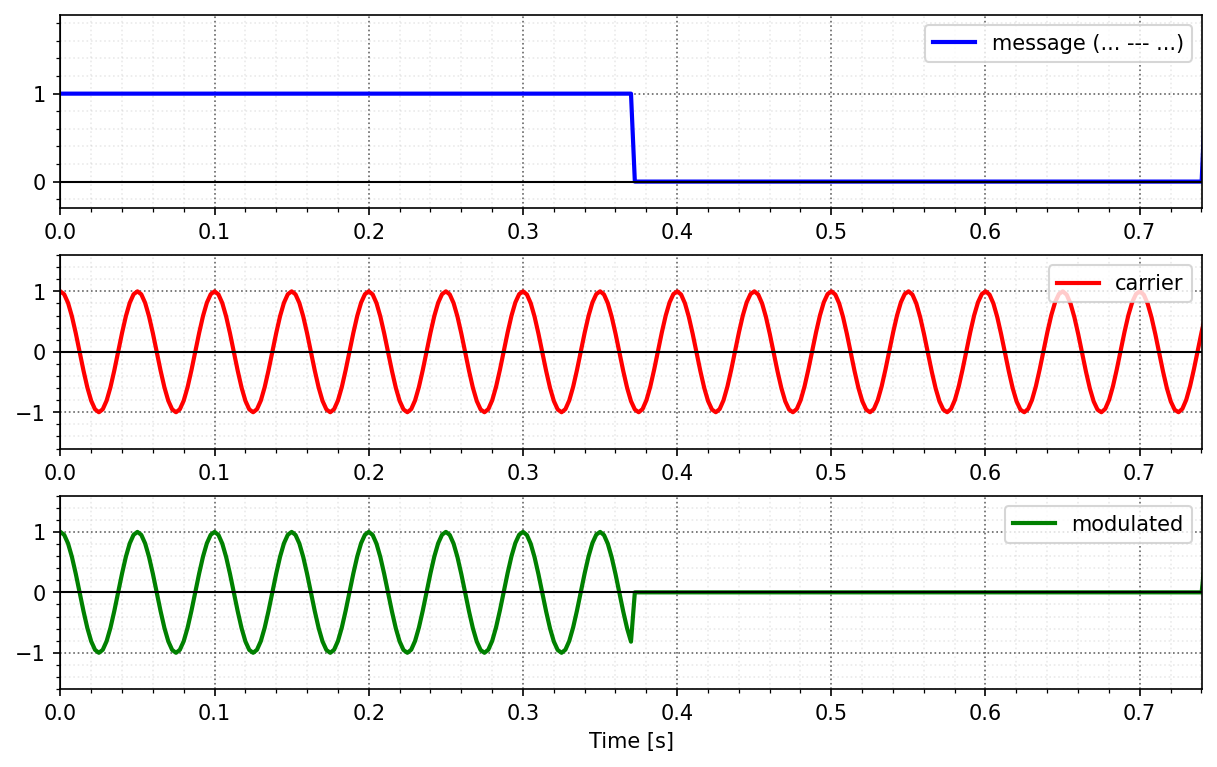

In [8]:
def morse_panels(xlim, fname):
    """Three-panel message / carrier / modulated plot over the window xlim."""
    fig, axs = plt.subplots(3,1,figsize=(8, 5),dpi=150,constrained_layout = True)
    axs[0].plot(t,y_message,'b-',lw=2,label=f'message ({morse_code})')
    axs[1].plot(t,y_carrier_morse,'r-',lw=2,label='carrier')
    axs[2].plot(t,y_modulated_morse,'g-',lw=2,label='modulated')
    for ii in np.arange(3):
        axs[ii].legend(loc='upper right')
        axs[ii].set_xlim(xlim)
        bm.nicegrid(axs[ii])
    # headroom so the legends clear the traces
    axs[0].set_ylim([-0.3,1.9])
    axs[1].set_ylim([-1.6,1.6])
    axs[2].set_ylim([-1.6,1.6])
    axs[-1].set_xlabel("Time [s]")
    plt.savefig(fname,  format='pdf', bbox_inches='tight', dpi=300)
    plt.show()

# Whole word: the message gates the carrier on and off
morse_panels([0,tf], './figs/AM_morse.pdf')

# Zoom on the first dot, where the switching is actually visible
morse_panels([0,2*dot], './figs/AM_morse_zoom.pdf')